# Sum of Square Spectral Amplification Resource Estimation

This notebook demonstrates how to use QDK Chemistry to construct a Sum of Squares Spectral Amplification (SOSSA) block-encoding circuit and perform resource estimation using QRE v3.
The goal is to enable users to understand and further improve on the fault-tolerant resource requirements of state-of-the-art quantum algorithms.

In addition to [installing `qdk-chemistry`](https://github.com/microsoft/qdk-chemistry/blob/main/INSTALL.md), you will need to install the `jupyter` and `qre` extras to run this notebook:

```bash
pip install 'qdk-chemistry[jupyter,qre]'
```

In [1]:
# Reduce logging output for demo
from qdk_chemistry.utils import Logger
Logger.set_global_level(Logger.LogLevel.off)

## Load a DFTHC factorized Hamiltonian

Load DFTHC tensors from a json file and construct a `FactorizedHamiltonianContainer`.

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

from qdk_chemistry.algorithms.controlled_circuit_mapper.sossa_mapper import SOSSAMapper
from qdk_chemistry.algorithms.hamiltonian_unitary_builder.block_encoding.sossa import SOSSABuilder
from qdk_chemistry.data import AlgorithmRef, BasisSet, FactorizedHamiltonianContainer, Hamiltonian, Orbitals, OrbitalType, Shell
from qdk_chemistry.data.unitary_representation.containers.sossa import SOSSAContainer

FACTORIZED_HAMILTONIAN_FILE = Path('data') / "h2_factorized_r1_b2_c1.hamiltonian.json"

hamiltonian = Hamiltonian.from_json(FACTORIZED_HAMILTONIAN_FILE.read_text())
factorized_hamiltonian = hamiltonian.get_container()
num_orbitals = factorized_hamiltonian.get_num_orbitals()
num_ranks, num_bases, num_copies = factorized_hamiltonian.get_num_ranks(), factorized_hamiltonian.get_num_bases(), factorized_hamiltonian.get_num_copies()
orbitals = factorized_hamiltonian.get_orbitals()

## Generate SOSSA Circuit

In [3]:
from qdk.widgets import Circuit

import qsharp
from qdk._interpreter import CircuitGenerationMethod

# Step 1: SOSSABuilder → UnitaryRepresentation
builder = SOSSABuilder()
unitary_rep = builder.run(factorized_hamiltonian)
container = unitary_rep.get_container()

# Step 2: SOSSAMapper → Circuit
mapper = SOSSAMapper()
mapper.settings().set("outer_prepare", AlgorithmRef("state_prep", "dense_pure_state"))
mapper.settings().set("inner_prepare_algorithm", "direct")
mapper.settings().set("select_algorithm", "direct")

circuit = mapper.run(unitary_rep)
factory = circuit._qsharp_factory
qs_circuit = qsharp.circuit(
    factory.program,
    *factory.parameter.values(),
    generation_method=CircuitGenerationMethod.Simulate,
)
Circuit(qs_circuit)

/tmp/ipykernel_6773/3280299705.py:3: DeprecationWarning: The 'qsharp' package is deprecated and will be removed in a future release. Please use the 'qdk' package instead. See https://github.com/microsoft/qdk/wiki/Migrating-from-qsharp-to-qdk for migration guidance.
  import qsharp


## Verify QPE simulation

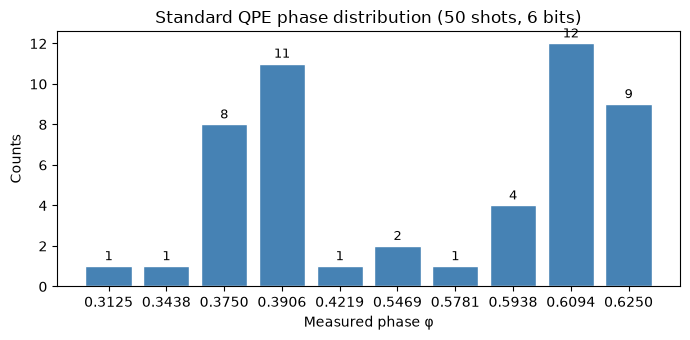

In [4]:
from qdk_chemistry.algorithms.phase_estimation.iterative_phase_estimation import IterativePhaseEstimation
from qdk_chemistry.data import AlgorithmRef, Configuration, Wavefunction, StateVectorContainer
from qdk_chemistry.data.circuit import Circuit, QsharpFactoryData
from qdk_chemistry.utils.qsharp import QSHARP_UTILS
from qdk_chemistry.algorithms.phase_estimation.standard_phase_estimation import StandardPhaseEstimation
from qdk_chemistry.algorithms.phase_estimation.circuit_builder.standard_builder import QdkStandardQpeCircuitBuilder
from qdk_chemistry.algorithms.circuit_executor.qdk import QdkSparseStateSimulator
import matplotlib.pyplot as plt
from collections import Counter
from qdk_chemistry.algorithms import create


# Build a single-determinant (HF) wavefunction and state preparation circuit
state_prep = create("state_prep", "sparse_isometry_gf2x")
hf_config = Configuration.canonical_hf_configuration(num_orbitals, num_orbitals, 2 * num_orbitals)
hf_wavefunction = Wavefunction(StateVectorContainer(hf_config, orbitals, "electrons"))
state_prep_circuit = state_prep.run(hf_wavefunction)

# Build QPE circuits with simulatable but not resource-efficient components
num_phase_bits_std = 6
std_builder = QdkStandardQpeCircuitBuilder(
    num_bits=num_phase_bits_std,
    controlled_circuit_mapper=AlgorithmRef(
        "controlled_circuit_mapper", "sossa",
        outer_prepare=AlgorithmRef("state_prep", "dense_pure_state"),
        inner_prepare_algorithm="direct",
        select_algorithm="direct",
    ),
    unitary_builder=AlgorithmRef("hamiltonian_unitary_builder", "sossa"),
)
std_circuits = std_builder.run(
    state_preparation=state_prep_circuit,
    qubit_hamiltonian=factorized_hamiltonian,
)
executor = QdkSparseStateSimulator()
result = executor.run(std_circuits[0], shots=50)

# Visualize the result distribution
counts = result.bitstring_counts
phase_counts = {}
for bitstring, count in result.bitstring_counts.items():
    phase = int(bitstring, 2) / (2**num_phase_bits_std)
    phase_counts[phase] = phase_counts.get(phase, 0) + count

labels = [f"{p:.4f}" for p in sorted(phase_counts)]
values = [phase_counts[p] for p in sorted(phase_counts)]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(labels, values, color="steelblue", edgecolor="white")
ax.set_xlabel("Measured phase φ")
ax.set_ylabel("Counts")
ax.set_title(f"Standard QPE phase distribution (50 shots, {num_phase_bits_std} bits)")
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## QRE v3 Resource Estimation

H2: queries=1571, num_phase_qubits=11


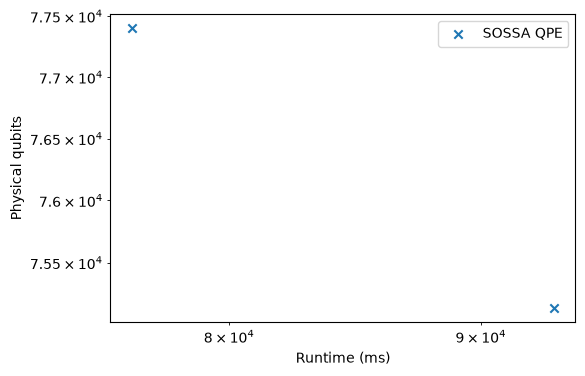

In [5]:
import math
from qdk_chemistry.algorithms.phase_estimation.circuit_builder.standard_builder import QdkStandardQpeCircuitBuilder
from qdk.qre import estimate, plot_estimates
from qdk.qre.models import Majorana, RoundBasedFactory, ThreeAux

# H2 parameters (small molecule — use modest precision)
b_rot_h2 = 10
b_coeff_h2 = 10
lambda_eff_h2 = 1.0
sigma_E = 1e-3

# Heisenberg-limited phase qubits
num_queries_h2 = math.ceil(math.pi * lambda_eff_h2 / (2 * sigma_E))
num_bits_qre_std = math.ceil(math.log2(num_queries_h2))
print(f"H2: queries={num_queries_h2}, num_phase_qubits={num_bits_qre_std}")

std_builder = QdkStandardQpeCircuitBuilder(
    num_bits=num_bits_qre_std,
    controlled_circuit_mapper=AlgorithmRef(
        "controlled_circuit_mapper", "sossa",
        outer_prepare=AlgorithmRef("state_prep", "alias_sampling"),
        inner_prepare_algorithm="controlled_alias_sampling",
        select_algorithm="qrom_phase_gradient",
        rotation_bit_precision=b_rot_h2,
        coefficient_bit_precision=b_coeff_h2,
    ),
    unitary_builder=AlgorithmRef("hamiltonian_unitary_builder", "sossa"),
)

std_circuits = std_builder.run(
    state_preparation=state_prep_circuit,
    qubit_hamiltonian=factorized_hamiltonian,
)
std_qpe_circuit = std_circuits[0]

app = std_qpe_circuit.get_qre_application()
architecture = Majorana(error_rate=1e-5)
isa_query = ThreeAux.q() * RoundBasedFactory.q(use_cache=True, code_query=ThreeAux.q())

qre_result = estimate(app, architecture, isa_query, max_error=0.01, name="SOSSA QPE")
plot_estimates(qre_result, figsize=(6, 4), runtime_unit="ms")

## Resource Estimation for Fake Data Generated based on R, B, C 

In [6]:
import math
import time

import numpy as np
import pandas as pd

from qdk_chemistry.data import (
    AlgorithmRef,
    FactorizedHamiltonianContainer,
    ModelOrbitals,
)
from qdk_chemistry.algorithms.controlled_circuit_mapper.sossa_mapper import SOSSAMapper
from qdk_chemistry.algorithms.hamiltonian_unitary_builder.block_encoding.sossa import SOSSABuilder
from qdk_chemistry.data.circuit import Circuit, QsharpFactoryData
from qdk_chemistry.utils.qsharp import QSHARP_UTILS
from qdk.qre import estimate, LatticeSurgery, PSSPC
from qdk.qre.models import Majorana, RoundBasedFactory, ThreeAux


def make_fake_factorized_hamiltonian(N, R, B, C, seed=42):
    """Create a fake FactorizedHamiltonianContainer with given (N, R, B, C)."""
    rng = np.random.default_rng(seed)
    h1 = rng.standard_normal((N, N))
    h1 = (h1 + h1.T) / 2

    u_matrices = np.zeros(R * B * N)
    for ri in range(R):
        for bi in range(B):
            v = rng.standard_normal(N)
            v /= np.linalg.norm(v)
            u_matrices[ri * B * N + bi * N : ri * B * N + (bi + 1) * N] = v

    w_matrices = rng.standard_normal(R * B * C) * 0.1
    wb_matrix = rng.standard_normal((R, C)) * 0.1
    orbitals = ModelOrbitals(N)
    inactive_fock = np.zeros((N, N))

    return FactorizedHamiltonianContainer(
        R, B, C, 0.0, u_matrices, w_matrices,
        h1, wb_matrix, inactive_fock, orbitals,
    )


molecules = [
    ("Fe2S2-20",  dict(N=20, R=14, B=15, C=5,  b_rot=15, b_coeff=11, lambda_eff=6.4690)),
    ("Fe4S4-36",  dict(N=36, R=9,  B=18, C=18, b_rot=17, b_coeff=13, lambda_eff=14.9842)),
    ("FeMoCo-54", dict(N=54, R=10, B=27, C=27, b_rot=15, b_coeff=15, lambda_eff=21.4486)),
    ("XVIII-56",  dict(N=56, R=5,  B=28, C=28, b_rot=12, b_coeff=7,  lambda_eff=17.0712)),
    ("FeMoCo-76", dict(N=76, R=15, B=57, C=19, b_rot=15, b_coeff=9,  lambda_eff=43.6538)),
]

sigma_E = 1e-3  # 1 mHa target precision
results_rows = []
architecture = Majorana(error_rate=1e-5)
isa_query = ThreeAux.q() * RoundBasedFactory.q(use_cache=True, code_query=ThreeAux.q())
trace_query = (
    PSSPC.q()
    * LatticeSurgery.q(slow_down_factor=[1.0 * j for j in range(1, 20)])
)

for label, params in molecules:
    t_start = time.perf_counter()

    # Heisenberg-limited queries
    num_queries = math.ceil(math.pi * params["lambda_eff"] / (2 * sigma_E))
    num_phase_qubits = math.ceil(math.log2(num_queries))

    factorized_hamiltonian = make_fake_factorized_hamiltonian(params["N"], params["R"], params["B"], params["C"])
    t_ham = time.perf_counter()

    std_builder = QdkStandardQpeCircuitBuilder(
        num_bits=num_phase_qubits,
        controlled_circuit_mapper=AlgorithmRef(
            "controlled_circuit_mapper", "sossa",
            outer_prepare=AlgorithmRef("state_prep", "alias_sampling"),
            inner_prepare_algorithm="controlled_alias_sampling",
            select_algorithm="qrom_phase_gradient",
            rotation_bit_precision=params["b_rot"],
            coefficient_bit_precision=params["b_coeff"],
        ),
        unitary_builder=AlgorithmRef("hamiltonian_unitary_builder", "sossa"),
    )
    orbitals = factorized_hamiltonian.get_orbitals()
    hf_config = Configuration.canonical_hf_configuration(params["N"], params["N"], 2 * params["N"])
    hf_wavefunction = Wavefunction(StateVectorContainer(hf_config, orbitals, "electrons"))
    state_prep_circuit = state_prep.run(hf_wavefunction)
    t_prep = time.perf_counter()

    std_circuits = std_builder.run(
        state_preparation=state_prep_circuit,
        qubit_hamiltonian=factorized_hamiltonian,
    )
    std_qpe_circuit = std_circuits[0]
    t_build = time.perf_counter()

    logical_count = std_qpe_circuit.estimate().logical_counts
    t_estimate = time.perf_counter()

    app = std_qpe_circuit.get_qre_application()
    qre_result = estimate(app, architecture, isa_query, trace_query, max_error=0.01, name=f"{label}")
    t_qre = time.perf_counter()

    if len(qre_result) == 0:
        raise ValueError("No results from resource estimation")

    r = qre_result[0]  # min qubit entry
    results_rows.append({
        "label": label,
        "logical_tof": logical_count["cczCount"],
        "logical_qubits": logical_count["numQubits"],
        "physical_qubits": r.qubits,
        "runtime": r.runtime,
        "error": r.error,
    })
    print(
        f"{label}: hamiltonian={t_ham - t_start:.2f}s, state_prep={t_prep - t_ham:.2f}s, "
        f"circuit_build={t_build - t_prep:.2f}s, logical_estimate={t_estimate - t_build:.2f}s, "
        f"qre={t_qre - t_estimate:.2f}s, total={t_qre - t_start:.2f}s"
    )

df = pd.DataFrame(results_rows)
df

Fe2S2-20: hamiltonian=0.00s, state_prep=0.09s, circuit_build=0.12s, logical_estimate=0.44s, qre=0.39s, total=1.04s
Fe4S4-36: hamiltonian=0.00s, state_prep=0.09s, circuit_build=0.12s, logical_estimate=1.15s, qre=1.19s, total=2.54s
FeMoCo-54: hamiltonian=0.00s, state_prep=0.13s, circuit_build=0.15s, logical_estimate=1.97s, qre=1.94s, total=4.18s
XVIII-56: hamiltonian=0.00s, state_prep=0.08s, circuit_build=0.10s, logical_estimate=0.95s, qre=0.98s, total=2.12s
FeMoCo-76: hamiltonian=0.00s, state_prep=0.09s, circuit_build=0.22s, logical_estimate=5.30s, qre=5.05s, total=10.67s


,label,logical_tof,logical_qubits,physical_qubits,runtime,error
0,Fe2S2-20,52327302,450,400573,10219320636000,0.006567
1,Fe4S4-36,192801028,809,804532,38007500279000,0.007033
2,FeMoCo-54,497279580,1052,1019533,79785043640000,0.007481
3,XVIII-56,174975780,879,850435,34343530963000,0.006859
4,FeMoCo-76,1601163336,1405,1698230,377642726266000,0.004031


## Fe2S2-20: MPS Sparse State Preparation + SOSSA QPE Resource Estimation

Combine MPS sparse initial state preparation (using real Fe2S2 tensors from the Rupprecht 2026 paper) with the
SOSSA block-encoding (fake factorized Hamiltonian with parameters from the Low2025 paper) to create a QPE circuit for full resource estimation of the Fe2S2 molecule.

This cell takes about 7 minutes to run.

MPSWavefunction: 20 sites, 40 qubits, bond_dims=[1, 4, 16, 64, 249, 742, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 871, 255, 64, 16, 4, 1]
MPS Sequential: Toffoli=12473297, qubits=245
QPE (total, incl. MPS): Toffoli=64800599, qubits=450

SOSSA QPE only (total - MPS): Toffoli=52327302
MPS Sequential State Prep:        Toffoli=12473297
Total (sanity check):          Toffoli=64800599


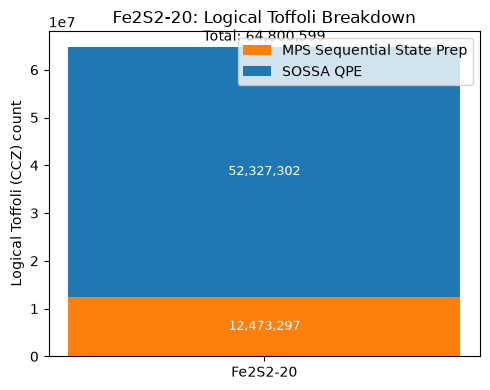


QRE v3 (full MPS+SOSSA QPE): 400573 physical qubits, runtime=12692755033000


In [7]:
import glob
from scipy.sparse import load_npz
from qdk_chemistry.data.mps_wavefunction import MPSWavefunction
from qdk_chemistry.algorithms.state_preparation.mps_sequential import MPSSequentialStatePreparation

# --- Fe2S2-20 parameters (reuse from molecules list above) ---
fe2s2_params = molecules[0][1]  # N=20, R=14, B=15, C=5, b_rot=15, b_coeff=11, lambda_eff=6.4690
PHASE_BITS = 10

# --- 1. MPS Sequential State Preparation (real Fe2S2 tensors) ---
COMPRESSED_PATH = Path("fe2s2-2_small") / "tensors_compressed" / "tensors_compressed_"
n_tensors = len(glob.glob(str(COMPRESSED_PATH) + "[0-9]*.npz"))
sparse_tensors = [load_npz(f"{COMPRESSED_PATH}{i}.npz") for i in range(n_tensors)]
dense_tensors = [t.toarray() for t in sparse_tensors]
mps = MPSWavefunction(dense_tensors)
print(f"MPSWavefunction: {mps.num_sites} sites, {mps.num_qubits} qubits, bond_dims={mps.bond_dims}")

algo_seq = MPSSequentialStatePreparation()
algo_seq.settings().set("rotation_bits", PHASE_BITS)
algo_seq.settings().set("fast_resource_estimation", True)
mps_circuit = algo_seq.run(mps)
mps_counts = mps_circuit.estimate().logical_counts
print(f"MPS Sequential: Toffoli={mps_counts['cczCount']}, qubits={mps_counts['numQubits']}")

# --- 2. SOSSA QPE with MPS state prep via QdkStandardQpeCircuitBuilder ---
fh = make_fake_factorized_hamiltonian(fe2s2_params["N"], fe2s2_params["R"], fe2s2_params["B"], fe2s2_params["C"])
num_queries = math.ceil(math.pi * fe2s2_params["lambda_eff"] / (2 * sigma_E))
num_phase_qubits = math.ceil(math.log2(num_queries))

qpe_builder = QdkStandardQpeCircuitBuilder(
    num_bits=num_phase_qubits,
    controlled_circuit_mapper=AlgorithmRef(
        "controlled_circuit_mapper", "sossa",
        outer_prepare=AlgorithmRef("state_prep", "alias_sampling"),
        inner_prepare_algorithm="controlled_alias_sampling",
        select_algorithm="qrom_phase_gradient",
        rotation_bit_precision=fe2s2_params["b_rot"],
        coefficient_bit_precision=fe2s2_params["b_coeff"],
    ),
    unitary_builder=AlgorithmRef("hamiltonian_unitary_builder", "sossa"),
)
qpe_circuits = qpe_builder.run(state_preparation=mps_circuit, qubit_hamiltonian=fh)
qpe_circuit = qpe_circuits[0]
qpe_total_counts = qpe_circuit.estimate().logical_counts
print(f"QPE (total, incl. MPS): Toffoli={qpe_total_counts['cczCount']}, qubits={qpe_total_counts['numQubits']}")

# --- 3. Subtract MPS cost to isolate SOSSA QPE cost ---
sossa_toffoli = qpe_total_counts["cczCount"] - mps_counts["cczCount"]
print(f"\nSOSSA QPE only (total - MPS): Toffoli={sossa_toffoli}")
print(f"MPS Sequential State Prep:        Toffoli={mps_counts['cczCount']}")

# --- 4. Stacked bar chart of logical Toffoli costs ---
fig, ax = plt.subplots(figsize=(5, 4))
labels = ["Fe2S2-20"]
mps_tof = [mps_counts["cczCount"]]
sossa_tof = [sossa_toffoli]

ax.bar(labels, mps_tof, label="MPS Sequential State Prep", color="tab:orange")
ax.bar(labels, sossa_tof, bottom=mps_tof, label="SOSSA QPE", color="tab:blue")
ax.set_ylabel("Logical Toffoli (CCZ) count")
ax.set_title("Fe2S2-20: Logical Toffoli Breakdown")
ax.legend()
for i, (m, q) in enumerate(zip(mps_tof, sossa_tof)):
    ax.text(i, m / 2, f"{m:,.0f}", ha="center", va="center", fontsize=9, color="white")
    ax.text(i, m + q / 2, f"{q:,.0f}", ha="center", va="center", fontsize=9, color="white")
total = qpe_total_counts["cczCount"]
ax.text(0, total * 1.02, f"Total: {total:,.0f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

# --- 5. Full QRE v3 (reuses architecture/isa_query from above) ---
app = qpe_circuit.get_qre_application()
qre_result = estimate(app, architecture, isa_query, max_error=0.01, name="Fe2S2-20 MPS+SOSSA QPE")
r = qre_result[0]
print(f"\nQRE v3 (full MPS+SOSSA QPE): {r.qubits} physical qubits, runtime={r.runtime}")
